In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

2026-06-08 12:59:27.257840: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 12:59:31.664713: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 12:59:33.821676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780923578.070637    4766 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780923578.902148    4766 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780923586.994955    4766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

TensorFlow: 2.19.0
Keras: 3.10.0


In [3]:
df = pd.read_csv('/workspaces/ml-supervised-dev/data/credito.csv')
print('Shape:', df.shape)
df.head()

Shape: (690, 16)


,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


Coluna alvo detectada: Approved
Distribuição da classe alvo:
Approved
0    383
1    307
Name: count, dtype: int64


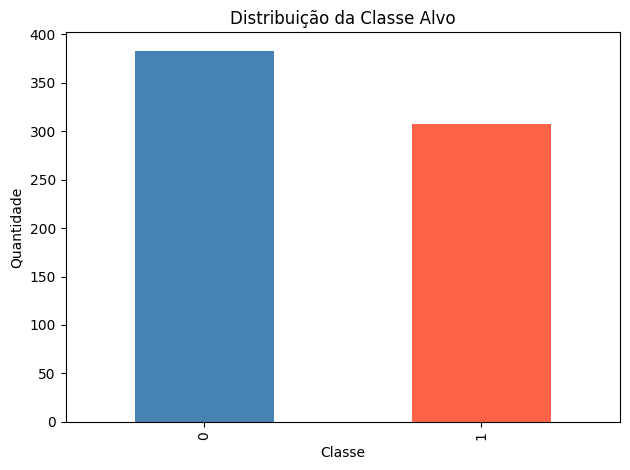

In [5]:
# Identificar coluna alvo (última coluna ou 'default'/'inadimplente')
# Ajuste o nome da coluna alvo conforme o seu CSV
TARGET_COL = df.columns[-1]   # <- muda aqui se necessário
print('Coluna alvo detectada:', TARGET_COL)
print('Distribuição da classe alvo:')
print(df[TARGET_COL].value_counts())
df[TARGET_COL].value_counts().plot(kind='bar', title='Distribuição da Classe Alvo', color=['steelblue','tomato'])
plt.xlabel('Classe'); plt.ylabel('Quantidade'); plt.tight_layout(); plt.show()

In [10]:
# --- EXECUTE ESTA CÉLULA ANTES DE RODAR O STANDARDSCALER ---

# 1. Carregar o conjunto de dados
df = pd.read_csv('/workspaces/ml-supervised-dev/data/credito.csv')

# 2. Codificar as variáveis categóricas de texto em colunas numéricas (0 e 1)
df_encoded = pd.get_dummies(df, columns=['Industry', 'Ethnicity', 'Citizen'], drop_first=True)

# 3. Garantir que as colunas booleanas (True/False) geradas virem inteiros (1 ou 0)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# 4. ATENÇÃO: Separar os previsores (X) a partir de df_encoded (E NÃO do df original)
X = df_encoded.drop(columns=['Approved'])
y = df_encoded['Approved']

# 5. Divisão estratificada: 70% Treino, 15% Validação, 15% Teste
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full)

print("Dados preparados com sucesso! Agora você pode rodar a célula do StandardScaler.")

Dados preparados com sucesso! Agora você pode rodar a célula do StandardScaler.


In [11]:
# Ajustar e transformar as características numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Monitora a perda de validação; se não houver melhoria por 20 épocas consecutivas, o treinamento para.
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Arquitetura: 1 camada oculta sutil (32 neurônios com ReLU)
model1 = Sequential([
    Dense(32, activation='relu', input_shape=(input_dim,)),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Treinando o Modelo 1...")
history1 = model1.fit(
    X_train_scaled, y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=150, 
    batch_size=16, 
    callbacks=[early_stopping], 
    verbose=0
)
print("Modelo 1 treinado com sucesso!")

2026-06-08 13:25:42.051638: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Treinando o Modelo 1...
Modelo 1 treinado com sucesso!


In [14]:
# Arquitetura: 2 camadas ocultas densas (64 e 32 neurônios com ReLU)
model2 = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Treinando o Modelo 2...")
history2 = model2.fit(
    X_train_scaled, y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=150, 
    batch_size=16, 
    callbacks=[early_stopping], 
    verbose=0
)
print("Modelo 2 treinado com sucesso!")

Treinando o Modelo 2...
Modelo 2 treinado com sucesso!


In [15]:
# Arquitetura: 2 camadas ocultas menores utilizando a função de ativação Tanh
model3 = Sequential([
    Dense(16, activation='tanh', input_shape=(input_dim,)),
    Dense(8, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Treinando o Modelo 3...")
history3 = model3.fit(
    X_train_scaled, y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=150, 
    batch_size=16, 
    callbacks=[early_stopping], 
    verbose=0
)
print("Modelo 3 treinado com sucesso!")

Treinando o Modelo 3...
Modelo 3 treinado com sucesso!


In [16]:
def obter_metricas(model, X_test_data, y_test_data):
    # Predições contínuas mapeadas para classes binárias (limiar de 0.5)
    preds = (model.predict(X_test_data) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test_data, preds)
    prec = precision_score(y_test_data, preds)
    rec = recall_score(y_test_data, preds)
    return acc, prec, rec, preds

# Avaliar todos os modelos na base de Teste
acc1, prec1, rec1, preds1 = obter_metricas(model1, X_test_scaled, y_test)
acc2, prec2, rec2, preds2 = obter_metricas(model2, X_test_scaled, y_test)
acc3, prec3, rec3, preds3 = obter_metricas(model3, X_test_scaled, y_test)

# Armazenar resultados em um DataFrame explicativo
resultados = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall'],
    'Modelo 1 (32 ReLU)': [acc1, prec1, rec1],
    'Modelo 2 (64+32 ReLU)': [acc2, prec2, rec2],
    'Modelo 3 (16+8 Tanh)': [acc3, prec3, rec3]
}).set_index('Métrica')

print("\nTabela Comparativa de Resultados obtidos na Base de Teste:")
display(resultados.round(4))

# Identificação automática do melhor modelo sob o critério de Recall
lista_recalls = [rec1, rec2, rec3]
modelos_lista = [model1, model2, model3]
nomes_modelos = ['Modelo 1', 'Modelo 2', 'Modelo 3']
melhor_idx = np.argmax(lista_recalls)

print(f"\n-> O modelo com o MAIOR RECALL é o {nomes_modelos[melhor_idx]} com o valor de: {lista_recalls[melhor_idx]:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x726d3c8345e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Tabela Comparativa de Resultados obtidos na Base de Teste:


,Modelo 1 (32 ReLU),Modelo 2 (64+32 ReLU),Modelo 3 (16+8 Tanh)
Métrica,,,
Acurácia,0.8846,0.8750,0.8750
Precisão,0.8864,0.9024,0.9024
Recall,0.8478,0.8043,0.8043



-> O modelo com o MAIOR RECALL é o Modelo 1 com o valor de: 0.8478


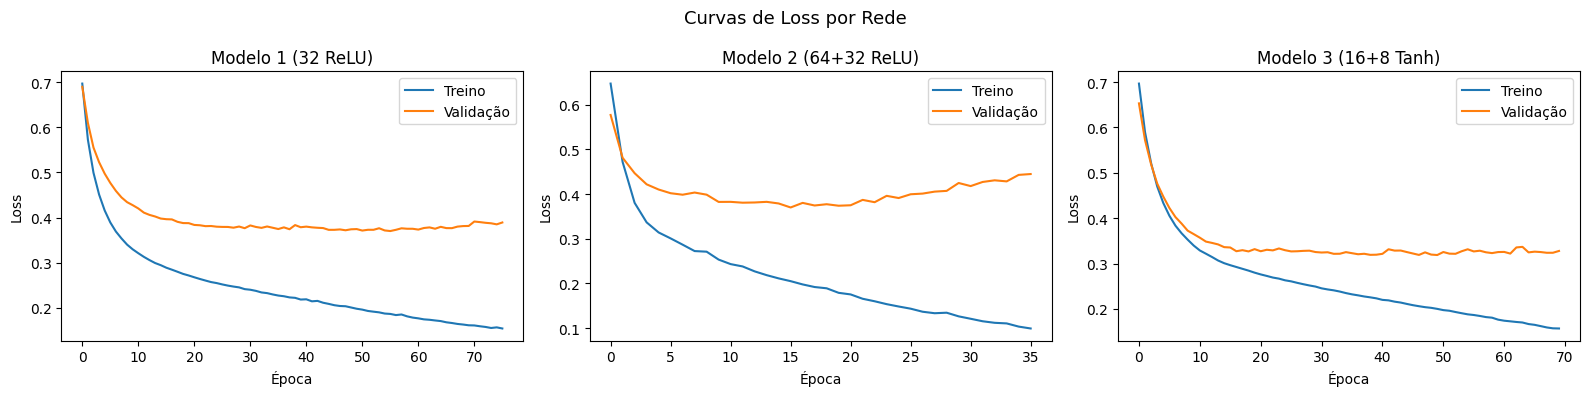

In [18]:
import matplotlib.pyplot as plt

# 1. Ajustamos aqui para os nomes exatos das variáveis do código anterior
historicos = [history1, history2, history3]

# 2. Ajustamos os nomes para refletir as arquiteturas criadas
nomes_modelos = ['Modelo 1 (32 ReLU)', 'Modelo 2 (64+32 ReLU)', 'Modelo 3 (16+8 Tanh)']

# Inicializa a figura com 1 linha e 3 colunas
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# Laço para desenhar os gráficos de cada modelo
for i, (hist, nome) in enumerate(zip(historicos, nomes_modelos)):
    axs[i].plot(hist.history['loss'], label='Treino')
    axs[i].plot(hist.history['val_loss'], label='Validação')
    axs[i].set_title(nome)
    axs[i].set_xlabel('Época')
    axs[i].set_ylabel('Loss')
    axs[i].legend()

# Título geral e ajustes de layout
plt.suptitle('Curvas de Loss por Rede', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Definir o modelo vencedor com base na célula anterior
melhor_modelo = modelos_lista[melhor_idx]

# Salvar o conjunto de pesos do modelo como artefato utilizando a extensão nativa padrão do Keras (.weights.h5)
melhor_modelo.save_weights('melhor_modelo_pesos.weights.h5')
print(f"Os pesos do {nomes_modelos[melhor_idx]} foram salvos com sucesso no arquivo 'melhor_modelo_pesos.weights.h5'!")

Os pesos do Modelo 1 (32 ReLU) foram salvos com sucesso no arquivo 'melhor_modelo_pesos.weights.h5'!


In [20]:
# Utilizando as predições do melhor modelo (identificado no teste anterior)
melhor_preds = preds2 if melhor_idx == 1 else (preds1 if melhor_idx == 0 else preds3)

# Criar o Pandas DataFrame de Comparação de Resultados
df_analise = pd.DataFrame({
    'Classe Real (Original)': y_test,
    'Resposta do Modelo': melhor_preds
})

# Classificar o resultado de cada predição
def classificar_predicao(row):
    real = row['Classe Real (Original)']
    pred = row['Resposta do Modelo']
    if real == 1 and pred == 1: return 'Verdadeiro Positivo (VP)'
    elif real == 0 and pred == 0: return 'Verdadeiro Negativo (VN)'
    elif real == 0 and pred == 1: return 'Falso Positivo (FP)'
    else: return 'Falso Negativo (FN)'

df_analise['Classificação'] = df_analise.apply(classificar_predicao, axis=1)

print("Exemplo das 20 primeiras amostras do DataFrame de análise de Teste:")
display(df_analise.head(20))

# Justificativa do Recall baseando-se nas contagens
print("\n--- JUSTIFICATIVA DO VALOR DE RECALL ---")
contagem = df_analise['Classificação'].value_counts()
vp = contagem.get('Verdadeiro Positivo (VP)', 0)
fn = contagem.get('Falso Negativo (FN)', 0)
vn = contagem.get('Verdadeiro Negativo (VN)', 0)
fp = contagem.get('Falso Positivo (FP)', 0)

recall_calculado = vp / (vp + fn) if (vp + fn) > 0 else 0

print(f"Verdadeiros Positivos (VP): {vp} (Casos onde o crédito era de fato aprovado e o modelo acertou)")
print(f"Falsos Negativos (FN): {fn} (Casos onde o crédito era aprovado, mas o modelo predisse incorretamente como negado)")
print(f"Fórmula do Recall: VP / (VP + FN) -> {vp} / ({vp} + {fn}) = {recall_calculado:.4f}")
print("\nAnálise Teórica: O recall avalia a capacidade do modelo de capturar instâncias da classe positiva. Os erros que prejudicam diretamente essa métrica são os Falsos Negativos. A tabela acima mapeia precisamente onde o modelo falhou em identificar os clientes elegíveis.")

Exemplo das 20 primeiras amostras do DataFrame de análise de Teste:


,Classe Real (Original),Resposta do Modelo,Classificação
351,0,0,Verdadeiro Negativo (VN)
560,1,1,Verdadeiro Positivo (VP)
191,1,0,Falso Negativo (FN)
683,0,0,Verdadeiro Negativo (VN)
558,1,1,Verdadeiro Positivo (VP)
567,1,1,Verdadeiro Positivo (VP)
166,1,1,Verdadeiro Positivo (VP)
204,1,1,Verdadeiro Positivo (VP)
511,1,1,Verdadeiro Positivo (VP)
152,1,1,Verdadeiro Positivo (VP)



--- JUSTIFICATIVA DO VALOR DE RECALL ---
Verdadeiros Positivos (VP): 39 (Casos onde o crédito era de fato aprovado e o modelo acertou)
Falsos Negativos (FN): 7 (Casos onde o crédito era aprovado, mas o modelo predisse incorretamente como negado)
Fórmula do Recall: VP / (VP + FN) -> 39 / (39 + 7) = 0.8478

Análise Teórica: O recall avalia a capacidade do modelo de capturar instâncias da classe positiva. Os erros que prejudicam diretamente essa métrica são os Falsos Negativos. A tabela acima mapeia precisamente onde o modelo falhou em identificar os clientes elegíveis.
